In [23]:
import matplotlib.pyplot as plt
import torch

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from model import autoencoderMLP4Layer

In [24]:
train_transform = transforms.Compose([transforms.ToTensor()])
train_set = MNIST('./data/mnist', train=True, download=True, transform=train_transform)

In [25]:
model = autoencoderMLP4Layer(N_input=784, N_bottleneck=8, N_output=784)
model.load_state_dict(torch.load('MLP.8.pth', map_location='cpu'))
model.eval()

autoencoderMLP4Layer(
  (fc1): Linear(in_features=784, out_features=392, bias=True)
  (fc2): Linear(in_features=392, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=392, bias=True)
  (fc4): Linear(in_features=392, out_features=784, bias=True)
)

label =  1


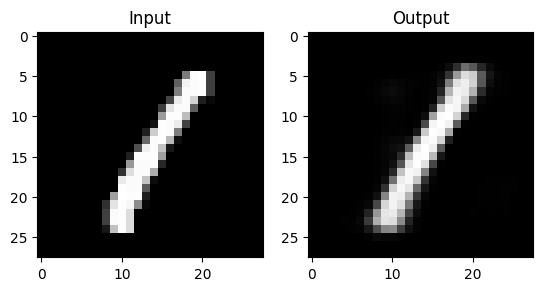

In [32]:
idx = int(input("Input an integer index between 0 and 59999: "))
if 0 <= idx <= train_set.data.size()[0]:
    print('label = ', train_set.targets[idx].item())

    inputImg = train_set.data[idx]
    inputImg = inputImg.type(torch.float32)
    inputImg = (inputImg - torch.min(inputImg)) / torch.max(inputImg)
    inputImg = inputImg.to('cpu')
    inputImg = inputImg.view(1, -1).type(torch.FloatTensor)

    with torch.no_grad():
        outputImg = model(inputImg)

    inputImg = inputImg.view(28, 28).type(torch.FloatTensor)
    outputImg = outputImg.view(28, 28).type(torch.FloatTensor)

    f = plt.figure()
    f.add_subplot(1,2,1)
    plt.imshow(inputImg, cmap='gray')
    plt.title('Input')
    f.add_subplot(1,2,2)
    plt.imshow(outputImg, cmap='gray')
    plt.title('Output')
    plt.show()